In [3]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.model_selection import train_test_split
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from collections import OrderedDict
from typing import Literal, Optional
from sklearn.metrics import f1_score
import copy
from matplotlib.ticker import FuncFormatter
from matplotlib.axes import Axes
from matplotlib.figure import Figure
import seaborn.objects as so
import math
import itertools
import matplotlib.ticker as mticker
import random

In [4]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

In [ ]:
data = pd.read_csv('Dataset/film_cleaned_ver2.csv')
df_needed = data[['cleaned_text', 'label']]
df_needed.head()

,cleaned_text,label
0,ta nói nó hài bản thân tôi con gái nhưng rất t...,positive
1,hên coi ở cgv phim gì nhân vật nói chả nghe cá...,negative
2,phim hài cười banh rạp = nửa tiếng đầu mình bi...,positive
3,nếu bỏ tiền mua vé xem phim việt tui tốn chưa ...,positive
4,phim hay ý nghĩa cười rất nhiều có nhìu hành đ...,positive


In [6]:
df_needed['label'].value_counts()

label
positive         2005
negative         1841
mixed/neutral    1233
none              328
Name: count, dtype: int64

In [7]:
# Loại bỏ đi Label là none có trong dữ liệu
df_needed = df_needed[df_needed['label'].isin(['positive', 'negative', 'mixed/neutral'])]

# Prepare data

In [8]:
# Xây dựng Vocabulary cho tập dữ liệu trên
def build_vocab(corpus: pd.Series) -> dict[str, int]:
    """
    Build vocabulary
    """
    # vectorize short_description to get the vocabulary
    vocab_vectorizer = CountVectorizer(min_df=1, max_df=1.0, stop_words=None)
    matrix = vocab_vectorizer.fit_transform(corpus)
    vocab = vocab_vectorizer.vocabulary_
    
    df = pd.DataFrame(list(vocab.items()), columns=['word', 'index'])
    df['index'] = df['index'] + 2

    df_pad = pd.DataFrame(list({"<PAD>": 0, "<UNK>": 1}.items()), columns=["word", "index"])
    df = pd.concat([df, df_pad], axis=0, ignore_index=True)
    
    vocab = dict(zip(df['word'], df['index']))
    
    return vocab

In [9]:
# Tạo dictionary để map label thành số
label = df_needed['label'].unique()
idx = range(len(label))
label_mapping = dict(zip(label, idx))
label_mapping

{'positive': 0, 'negative': 1, 'mixed/neutral': 2}

In [10]:
# Chia tập dữ liệu thành train, val, test dataset
X = df_needed['cleaned_text']
y = df_needed['label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, stratify=y, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size = 0.2, stratify=y_train, random_state=42)

In [11]:
vocab=build_vocab(X_train)
len(vocab)

4913

In [ ]:
from torch.nn.utils.rnn import pad_sequence
class SentimentDataset(Dataset):
    def __init__(self, vocab, text: pd.Series, label: pd.Series, label_mapping):
        super().__init__()
        self.vocab = vocab
        self.text = text
        self.label = label
        self.label_mapping = label_mapping

    def __len__(self):
        return len(self.text)

    def __getitem__(self, idx) -> tuple[torch.LongTensor, torch.LongTensor]:  # iterate through each sample, must have "idx"
        # get text at index
        text_item = self.text.iloc[idx]
        label_item = self.label.iloc[idx]

        # tokenize
        tokens = text_item.split()
        tokens_idx = [self.vocab[token] if token in self.vocab else self.vocab['<UNK>'] for token in tokens] # list
        label_idx = self.label_mapping[label_item]

        return torch.tensor(tokens_idx, dtype=torch.long), torch.tensor(label_idx, dtype=torch.long)

def collate_fn(batch) -> tuple[torch.LongTensor, torch.LongTensor]:
    tokens_idx, label = zip(*batch) # return tuples
    labels = torch.stack(label, dim=0)
    
    # Pad the sequences
    padded_sequences = pad_sequence(tokens_idx, batch_first=True,
                                    padding_value=vocab["<PAD>"])
    
    return padded_sequences, labels

In [13]:
train_dataset = SentimentDataset(vocab=vocab, label_mapping=label_mapping,
                                    text=X_train, label=y_train)

val_dataset = SentimentDataset(vocab=vocab, label_mapping=label_mapping,
                                    text=X_val, label=y_val)

test_dataset = SentimentDataset(vocab=vocab, label_mapping=label_mapping,
                                    text=X_test, label=y_test)

In [14]:
train_loader = DataLoader(train_dataset, batch_size = 512, shuffle=True, collate_fn = collate_fn)

val_loader = DataLoader(val_dataset, batch_size = 512, shuffle=False, collate_fn = collate_fn)

test_loader = DataLoader(test_dataset, batch_size = 512, shuffle=False, collate_fn = collate_fn)

# used to create mini-batch

# Build RNN model

In [48]:
# Huấn luyện mô hình
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 50

loss_function = nn.CrossEntropyLoss()
metric_fn = f1_score

rnn_params = {'vocab': vocab, 
              'emb_dim': 128, 
              'num_classes': y_train.nunique(),
              'hidden_size': 128,
              'num_layers': 1,
              'pooling_fn': 'attention',
              'bidirectional': False,}

In [ ]:
from helper_class import ModelTraining
from Model.rnn import RNNModel

model = RNNModel(**rnn_params)
model = torch.nn.DataParallel(model)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr= 0.001) # weight_decay=1e-2

performance = ModelTraining(model=model, optimizer=optimizer, loss_function=loss_function,
                             device=device, train_loader=train_loader, val_loader=val_loader,
                             test_loader=test_loader)

In [61]:
train_loss_collection, val_loss_collection, train_score_collection, val_score_collection, best_state = \
performance.training_session(epochs=epochs, metric_fn=metric_fn, kwargs={'average': 'macro'})

New best score in epoch 1: 0.4357365632411169. Saving model parameters...
Epoch 1 completed
Train Loss: 1.1171 ; Score: 0.3257044906356282
Val Loss: 1.0393 ; Score: 0.4357365632411169
Epoch 2 completed
Train Loss: 1.0747 ; Score: 0.33930450741949797
Val Loss: 1.0149 ; Score: 0.34088289717155695
New best score in epoch 3: 0.454117300757966. Saving model parameters...
Epoch 3 completed
Train Loss: 1.0455 ; Score: 0.3648891231123505
Val Loss: 0.9310 ; Score: 0.454117300757966
New best score in epoch 4: 0.5217271991122919. Saving model parameters...
Epoch 4 completed
Train Loss: 0.9785 ; Score: 0.44311999889616044
Val Loss: 0.7770 ; Score: 0.5217271991122919
New best score in epoch 5: 0.5633275609191839. Saving model parameters...
Epoch 5 completed
Train Loss: 0.8639 ; Score: 0.49232443451329666
Val Loss: 0.7386 ; Score: 0.5633275609191839
New best score in epoch 6: 0.5989362009779325. Saving model parameters...
Epoch 6 completed
Train Loss: 0.8269 ; Score: 0.5513226433775383
Val Loss: 0.7

In [62]:
df_train = pd.DataFrame({'loss': train_loss_collection,
                        'score': train_score_collection,
                        'type': "train"})

df_val = pd.DataFrame({'loss': val_loss_collection,
                        'score': val_score_collection,
                        'type': "val"})
df = pd.concat((df_train, df_val), axis=0).reset_index()
df['index'] = df['index'] + 1

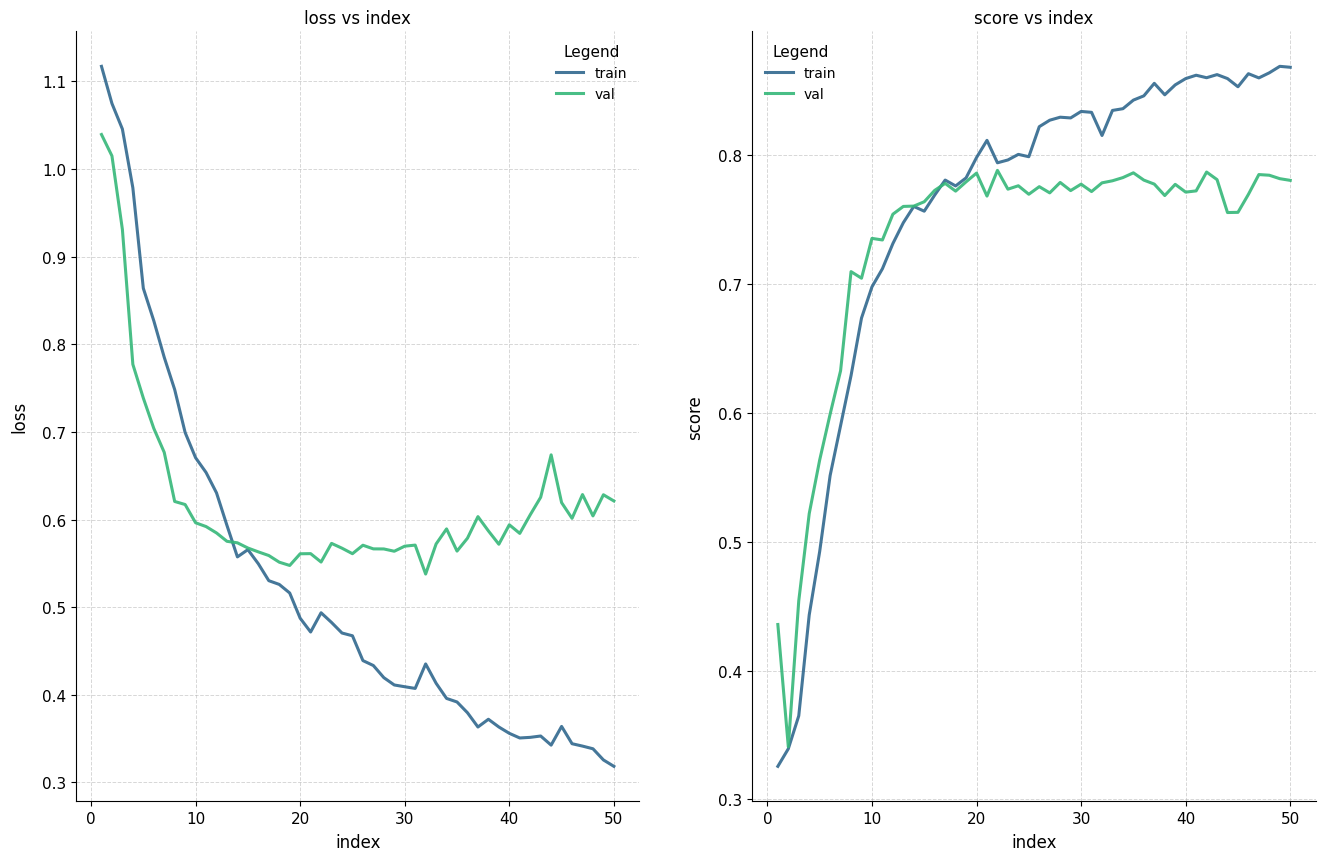

In [ ]:
from visualisation import LinePlot

X = ['index', 'index']
y = ['loss', 'score']
hue = ['type', 'type']
style_list = [None for _ in range(2)]
size_list = [None for _ in range(2)]

plotter = LinePlot(df)
fig, axes = plotter.multiple_plots(x_axis_list=X, y_axis_list=y, hue_list=hue,
                                      style_list=style_list, size_list=size_list, plots_each_row=2,
                                      kwarg={}, readable_label=False)

In [64]:
test_loss, test_score = performance.testing(metric_fn=metric_fn, kwargs={'average': 'macro'})

Test Loss: 0.5641333489400434 ; Score: 0.7771485969131867


In [ ]:
import os
best_path = os.path.join('Trained Model', "best_stacked_rnn_model.pth") 

torch.save({
    "model_state": best_state,
    "model_class": model.__class__.__name__,
    "model_args": rnn_params,
    "optimizer_state": optimizer.state_dict(),
    "epochs": epochs
}, best_path)